# Prepare the labeled multi-view Poomsae dataset

This notebook is the final preprocessing stage before model development. It creates exactly one sample per player performance by:

1. parsing `WP1.txt` through `WP54.txt` into accuracy, presentation, negative, and total targets;
2. matching each label to the same `WPn` pose directory;
3. filtering low-confidence frames and excluding unreliable camera views;
4. summarizing every camera independently—2D values from different cameras are never averaged;
5. exporting joined, feature-only, target-only, and quality-control tables.

The exported dataset remains player-level. All future train/test splits must use `player_id`, never individual video frames.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from poomsae_scoring.scoring.dataset_preparation import (
    DatasetPreparationConfig,
    prepare_multiview_dataset,
    write_prepared_dataset,
)


## Configuration

A camera view is retained only when at least 80% of its frames contain a detected pose, at least 50% pass the mean-landmark-confidence threshold, and at least 30 usable frames remain. An excluded view keeps its quality indicators while its pose summaries remain missing, allowing a later imputation pipeline to use the other cameras without treating bad detections as real body motion.

In [2]:
LABELS_ROOT = PROJECT_ROOT / "data/label/Women-score-txt"
PLAYERS_ROOT = PROJECT_ROOT / "data/processed/players"
OUTPUT_ROOT = PROJECT_ROOT / "data/processed/model_ready"

config = DatasetPreparationConfig(
    angles=("0", "45", "135"),
    minimum_detection_rate=0.80,
    minimum_mean_keypoint_confidence=0.50,
    minimum_usable_frame_rate=0.50,
    minimum_usable_frames=30,
)

assert LABELS_ROOT.is_dir(), f"Missing label directory: {LABELS_ROOT}"
assert PLAYERS_ROOT.is_dir(), f"Missing player directory: {PLAYERS_ROOT}"
print(f"Labels: {LABELS_ROOT}")
print(f"Pose features: {PLAYERS_ROOT}")
print(f"Prepared output: {OUTPUT_ROOT}")

Labels: /home/nazi/Desktop/poomsae-scoring-system/data/label/Women-score-txt
Pose features: /home/nazi/Desktop/poomsae-scoring-system/data/processed/players
Prepared output: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready


## Parse, match, filter, and aggregate

For each reliable view and numeric frame feature, the preparation code stores median, standard deviation, 10th percentile, and 90th percentile. It also calculates median and 90th-percentile absolute velocity using consecutive frames only. Support-side proportions and switching rate preserve additional temporal information.

In [3]:
prepared = prepare_multiview_dataset(
    labels_root=LABELS_ROOT,
    players_root=PLAYERS_ROOT,
    config=config,
)

print(f"Player-level samples: {len(prepared.dataset)}")
print(f"Pose/quality feature columns: {prepared.features.shape[1] - 1}")
print(f"Camera views checked: {len(prepared.quality_report)}")
display(prepared.targets.head())

Player-level samples: 54
Pose/quality feature columns: 336
Camera views checked: 162


,player_id,score_accuracy,score_presentation,score_negative,score_total
0,WP1,3.13,4.60,0.0,7.73
1,WP2,2.90,4.30,0.0,7.20
2,WP3,3.00,4.60,0.0,7.60
3,WP4,3.03,4.43,0.0,7.46
4,WP5,2.83,4.36,0.0,7.19


## Validate matching and targets

These checks stop the workflow if a label is duplicated, a `WPn` directory is missing, a score total is inconsistent, or the final join loses a player.

In [5]:
assert prepared.targets["player_id"].is_unique
assert prepared.features["player_id"].is_unique
assert prepared.dataset["player_id"].is_unique
assert len(prepared.dataset) == len(prepared.targets) == len(prepared.features)
assert prepared.dataset["score_total"].between(0, 10).all()
assert (
    prepared.dataset["score_total"]
    - prepared.dataset["score_accuracy"]
    - prepared.dataset["score_presentation"]
    + prepared.dataset["score_negative"]
).abs().le(0.011).all()

print("Player matching and score consistency checks passed.")
display(prepared.targets.describe().round(3))

Player matching and score consistency checks passed.


,score_accuracy,score_presentation,score_negative,score_total
count,54.000,54.000,54.0,54.000
mean,3.007,4.439,0.0,7.446
std,0.112,0.164,0.0,0.268
min,2.760,4.030,0.0,6.860
25%,2.930,4.330,0.0,7.230
50%,3.030,4.460,0.0,7.475
75%,3.060,4.530,0.0,7.600
max,3.200,4.800,0.0,7.960


## Camera quality report

Review excluded views before modeling. A low-quality view is represented by missing pose summaries plus explicit reliability and detection-rate columns. Do not replace its missing summaries with zeros.

In [6]:
quality_summary = (
    prepared.quality_report.groupby(["angle", "quality_status"], observed=True)
    .size()
    .rename("views")
    .reset_index()
)
display(quality_summary)

excluded_views = prepared.quality_report.loc[
    ~prepared.quality_report["reliable"],
    [
        "player_id",
        "angle",
        "detection_rate",
        "usable_frame_rate",
        "mean_keypoint_confidence",
        "duration_seconds",
    ],
].copy()
excluded_views[["detection_rate", "usable_frame_rate", "mean_keypoint_confidence"]] = (
    excluded_views[["detection_rate", "usable_frame_rate", "mean_keypoint_confidence"]]
    .round(3)
)
display(excluded_views)

,angle,quality_status,views
0,0,excluded_low_quality,3
1,0,usable,51
2,135,excluded_low_quality,3
3,135,usable,51
4,45,excluded_low_quality,4
5,45,usable,50


,player_id,angle,detection_rate,usable_frame_rate,mean_keypoint_confidence,duration_seconds
2,WP1,135,0.556,0.556,0.849,52.02
11,WP4,135,0.000,0.000,NaN,46.72
14,WP5,135,0.759,0.759,0.892,48.26
37,WP13,45,0.279,0.279,0.797,42.92
63,WP22,0,0.023,0.023,0.720,46.44
76,WP26,45,0.720,0.720,0.804,45.50
79,WP27,45,0.267,0.267,0.814,52.14
87,WP30,0,0.720,0.720,0.830,49.50
132,WP45,0,0.637,0.637,0.768,46.42
151,WP51,45,0.241,0.241,0.839,47.10


## Inspect missingness and label distributions

Missing pose summaries should be concentrated in the deliberately excluded views. Imputation, scaling, and feature selection belong inside the cross-validation pipeline in the next modeling stage, so they are intentionally not fitted here.

,angle,feature_columns,missing_cells,excluded_views
0,0,110,318,3
1,45,110,424,4
2,135,110,319,3


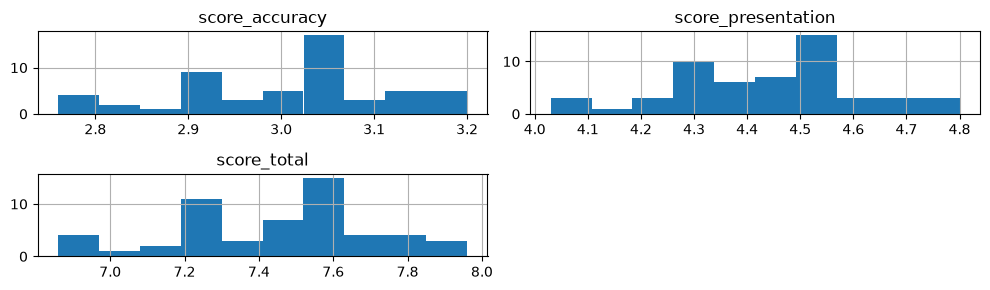

In [7]:
missing_by_view = []
for angle in config.angles:
    view_columns = [
        column
        for column in prepared.features.columns
        if column.startswith(f"view_{angle}_")
        and not column.endswith(("_available", "_reliable"))
    ]
    missing_by_view.append(
        {
            "angle": angle,
            "feature_columns": len(view_columns),
            "missing_cells": int(prepared.features[view_columns].isna().sum().sum()),
            "excluded_views": int(
                (prepared.features[f"view_{angle}_reliable"] == 0).sum()
            ),
        }
    )
display(pd.DataFrame(missing_by_view))

prepared.targets[
    ["score_accuracy", "score_presentation", "score_total"]
].hist(figsize=(10, 3), bins=10)
plt.tight_layout()
plt.show()

## Export model-ready preprocessing outputs

- `prepared_dataset.csv`: labels and features joined into one player-level table
- `features.csv`: `player_id` plus camera-specific predictors; no score columns
- `targets.csv`: `player_id` plus score targets
- `quality_report.csv`: one row per player-camera pair
- `metadata.json`: thresholds, dimensions, and data-use notes

In [8]:
output_paths = write_prepared_dataset(
    prepared=prepared,
    output_directory=OUTPUT_ROOT,
    config=config,
)

for name, path in output_paths.items():
    print(f"{name:>14}: {path}")

reloaded_dataset = pd.read_csv(output_paths["dataset"])
assert reloaded_dataset.shape == prepared.dataset.shape
assert reloaded_dataset["player_id"].tolist() == prepared.dataset["player_id"].tolist()
print(f"\nExport verified: {reloaded_dataset.shape[0]} rows x {reloaded_dataset.shape[1]} columns")

       dataset: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready/prepared_dataset.csv
      features: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready/features.csv
       targets: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready/targets.csv
quality_report: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready/quality_report.csv
      metadata: /home/nazi/Desktop/poomsae-scoring-system/data/processed/model_ready/metadata.json

Export verified: 54 rows x 341 columns


## Handoff to modeling

The preprocessing stage is complete after the export cell succeeds. The next notebook should predict `score_accuracy` and `score_presentation` separately, derive total score from those predictions, and evaluate with player-level cross-validation. Missing-value imputation, scaling, and feature selection must be fitted inside each training fold.